In [1]:

"""
不要只看当前这一步梯度,也可以参考过去一段时间的更新方向
"""
from collections.abc import Iterator
from pprint import pprint
from typing import override, Iterable, Any

import dnnlpy
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

print('Torch Version:', torch.__version__)

Torch Version: 2.13.0+cpu


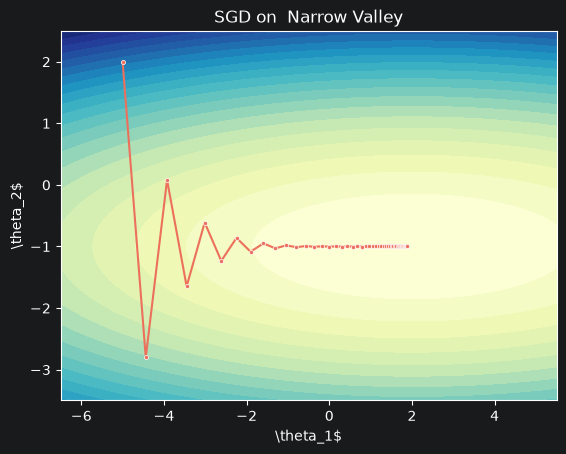

In [2]:
"""
SGD 为什么会抖动
"""


def loss_fn(theta: Tensor) -> Tensor:
    x, y = theta[0], theta[1]
    return 0.1 * (x - 2) ** 2 + 2 * (y + 1) ** 2


theta = torch.tensor([-5.0, 2.0], requires_grad=True)
optimizer = dopt.SGD([theta], lr=0.4)
history = dopt.run_optimizer(optimizer, loss_fn, steps=50)

x = torch.linspace(-6.5, 5.5, 200)
y = torch.linspace(-3.5, 2.5, 200)
X, Y = torch.meshgrid(x, y, indexing='ij')
Z = 0.1 * (X - 2) ** 2 + 2 * (Y + 1) ** 2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.contourf(X, Y, Z, levels=25, cmap="YlGnBu")
ax.plot(history[:, 0], history[:, 1], color='#EC705B', marker='o', markersize=3, markeredgecolor='white',
        markerfacecolor='#EC705B', markeredgewidth=0.5)

ax.set_xlabel(r'\theta_1$')
ax.set_ylabel(r'\theta_2$')
ax.set_title("SGD on  Narrow Valley")
plt.show()

In [3]:
"""
Momentum: 让更新方向更有惯性
"""

'\nMomentum: 让更新方向更有惯性\n'

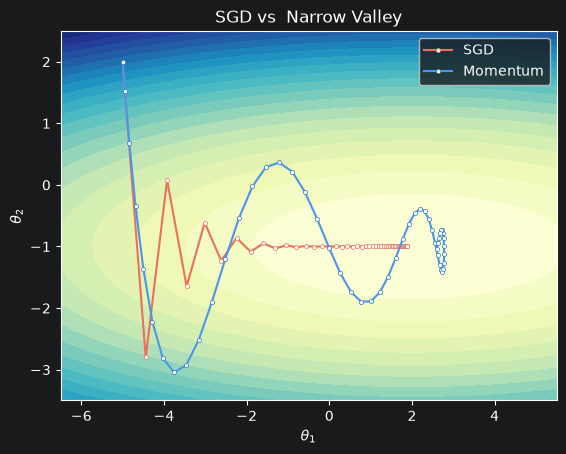

In [4]:
"""
Momentum 与SGD 的轨迹对比
"""


class SimpleSGDWithMomentum(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 1e-3, momentum: float = 0.0):
        super().__init__(params)
        self.lr = lr
        self.momentum = momentum
        self.velocity = [torch.zeros_like(p) for p in self.params]

    @override
    @torch.no_grad()
    def step(self):
        for p, v in zip(self.params, self.velocity, strict=True):
            if p.grad is None:
                continue
            v.mul_(self.momentum).add_(p.grad)
            p.sub_(v, alpha=self.lr)


theta1 = torch.tensor([-5.0, 2.0], requires_grad=True)
theta2 = torch.tensor([-5.0, 2.0], requires_grad=True)

optimizer1 = dopt.SGD([theta1], lr=0.4)
optimizer2 = SimpleSGDWithMomentum([theta2], lr=0.04, momentum=0.9)

sgd_history = dopt.run_optimizer(optimizer1, loss_fn, steps=50)
momentum_history = dopt.run_optimizer(optimizer2, loss_fn, steps=50)

fig = plt.figure(2)
ax = fig.add_subplot(1, 1, 1)
ax.contourf(X, Y, Z, levels=25, cmap="YlGnBu")

ax.plot(
    sgd_history[:, 0],
    sgd_history[:, 1],
    color='#EC705B',
    marker='o',
    markersize=3,
    markeredgecolor='#EC705B',
    markerfacecolor='white',
    markeredgewidth=0.5
)

ax.plot(
    momentum_history[:, 0],
    momentum_history[:, 1],
    color='#4B96EB',
    marker='o',
    markersize=3,
    markeredgecolor='#2A74CB',
    markerfacecolor='white',
    markeredgewidth=0.5

)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.legend(['SGD', 'Momentum'])
ax.set_title("SGD vs  Narrow Valley")
plt.show()

In [6]:
"""
pytorch中的momentum
"""

model = nn.Linear(6, 1)
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
)

x = torch.randn(32,6)
y = torch.randn(32,1)

pred =  model(x)
loss = F.mse_loss(pred,y)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("loss:",loss.item())




loss: 1.0891058444976807


In [ ]:
"""
Nesterov Momentum:先往前看一眼
"""

In [ ]:
"""
Momentum的作用和局限性
    - 优点
        1. 减少震荡,如果某个梯度来回变化,momentum会让正负方向相互抵消,从而减少震荡
        2. 加速一致方向,如果很多步的梯度方向相似,momentum会不断的累计这个方向,让参数更新更快
        3. 引入优化器状态,由于momentum需要维护速度变量, 因此optimizer 不再是无状态的更新规则
    - 缺点
        所有参数仍然是共享一个全局学习率
"""
